# Experiment 4: Data Wrangling and Data Visualization
## Mallari, Lance Joseph N.
### 2ECE-A
### 09/19/2026


## Problem A: VISAYAS COMMUNICATION DATAFRAME

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset and clean column headers
df = pd.read_csv("board2.csv")
df.columns = df.columns.str.strip()

# Calculate "Average" column if missing from the CSV
if "Average" not in df.columns:
    df["Average"] = df[["Math", "GEAS", "Electronics", "Communication"]].mean(
        axis=1
    )

In [27]:
# Filter Hometown == 'Visayas' and Track == 'Communication' before column selection
VisComm = df[(df["Hometown"] == "Visayas") & (df["Track"] == "Communication")][
    ["Name", "Gender", "Math", "Electronics", "Average"]
]

# Display DataFrame and row count
display(VisComm)
print(f"Number of rows in VisComm: {len(VisComm)}")

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


Number of rows in VisComm: 5


## Problem B: VISAYAS FEMALE DATAFRAME

In [28]:
# Filter Hometown == 'Visayas' and Gender == 'Female' before column selection
VisFemale = df[(df["Hometown"] == "Visayas") & (df["Gender"] == "Female")][
    ["Name", "Track", "GEAS", "Electronics", "Average"]
]

# Display VisFemale
print(" VisFemale DataFrame ")
display(VisFemale)

# Display rows where Average is at least 60 without overwriting VisFemale
print("\n VisFemale Students with Average >= 60 ")
vis_female_passed = VisFemale[VisFemale["Average"] >= 60]
display(vis_female_passed)

 VisFemale DataFrame 


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75



 VisFemale Students with Average >= 60 


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


## Problem C: CATEGORY-AVERAGE VISUALIZATION

 [Summary Table: Mean Average by Track] 


,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500



 [Summary Table: Mean Average by Gender] 


,Gender,Average
0,Female,66.616667
1,Male,67.183333



 [Summary Table: Mean Average by Hometown] 


,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


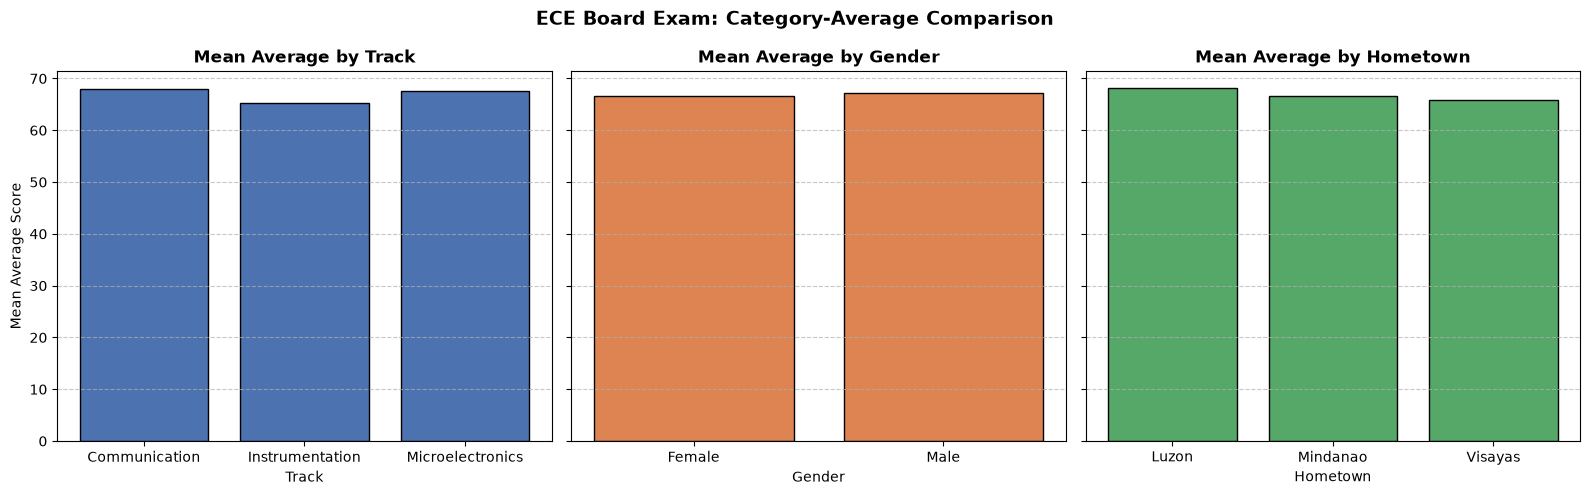

In [29]:
# a & b. Compute and display category means
track_avg = df.groupby("Track", as_index=False)["Average"].mean()
gender_avg = df.groupby("Gender", as_index=False)["Average"].mean()
hometown_avg = df.groupby("Hometown", as_index=False)["Average"].mean()

print(" [Summary Table: Mean Average by Track] ")
display(track_avg)

print("\n [Summary Table: Mean Average by Gender] ")
display(gender_avg)

print("\n [Summary Table: Mean Average by Hometown] ")
display(hometown_avg)

# c. Create one figure containing three bar charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

# Bar plot 1: Track
axes[0].bar(
    track_avg["Track"],
    track_avg["Average"],
    color="#4C72B0",
    edgecolor="black",
)
axes[0].set_title("Mean Average by Track", fontweight="bold")
axes[0].set_xlabel("Track")
axes[0].set_ylabel("Mean Average Score")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Bar plot 2: Gender
axes[1].bar(
    gender_avg["Gender"],
    gender_avg["Average"],
    color="#DD8452",
    edgecolor="black",
)
axes[1].set_title("Mean Average by Gender", fontweight="bold")
axes[1].set_xlabel("Gender")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# Bar plot 3: Hometown
axes[2].bar(
    hometown_avg["Hometown"],
    hometown_avg["Average"],
    color="#55A868",
    edgecolor="black",
)
axes[2].set_title("Mean Average by Hometown", fontweight="bold")
axes[2].set_xlabel("Hometown")
axes[2].grid(axis="y", linestyle="--", alpha=0.7)

plt.suptitle(
    "ECE Board Exam: Category-Average Comparison",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()